In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

df=pd.read_csv("Titanic-Dataset.csv")

df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [2]:
df=pd.get_dummies(df,columns=["Sex","Embarked"],drop_first=True)
df=df.drop(columns=["Name","Cabin","Ticket"])
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
Sex_male         0
Embarked_Q       0
Embarked_S       0
dtype: int64


In [4]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [5]:
df["Embarked_Q"]=df["Embarked_Q"].fillna(df["Embarked_Q"].mean())
df["Embarked_S"]=df["Embarked_S"].fillna(df["Embarked_S"].mean())

In [6]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64


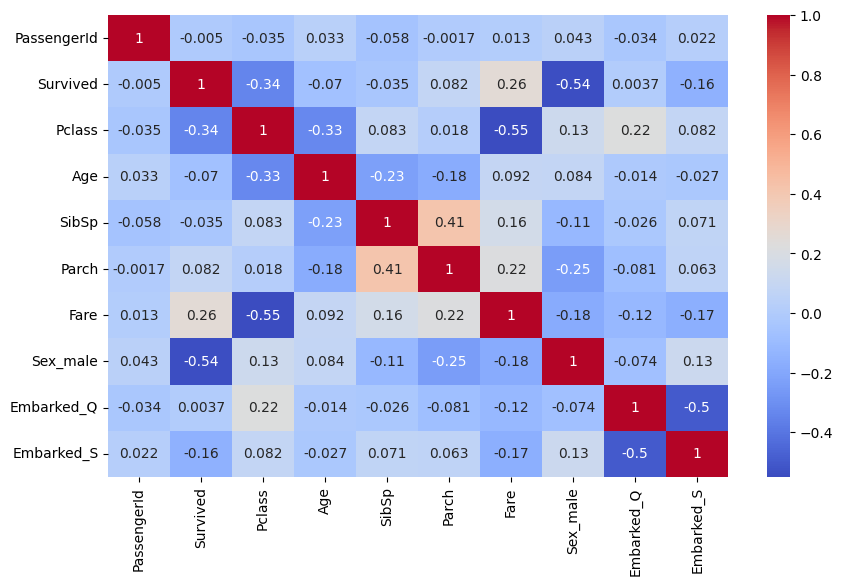

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [9]:
knn=KNeighborsClassifier(n_neighbors=3)
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Sex_male          bool
Embarked_Q        bool
Embarked_S        bool
dtype: object

In [10]:
X=df.drop(columns=["Survived"])
y=df["Survived"]

In [11]:
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42,test_size=0.2)

ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [12]:
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
ac=accuracy_score(y_test,y_pred)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Report: ",classification_report(y_test,y_pred))

Accuracy:  0.8044692737430168
Report:                precision    recall  f1-score   support

           0       0.84      0.83      0.83       105
           1       0.76      0.77      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [13]:
nb=GaussianNB()
nb.fit(X_train,y_train)
y_pred2=nb.predict(X_test)
ac1=accuracy_score(y_test,y_pred2)
print("Accuracy: ",accuracy_score(y_test,y_pred2))
print("Report: ",classification_report(y_test,y_pred2))

Accuracy:  0.770949720670391
Report:                precision    recall  f1-score   support

           0       0.81      0.80      0.80       105
           1       0.72      0.73      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



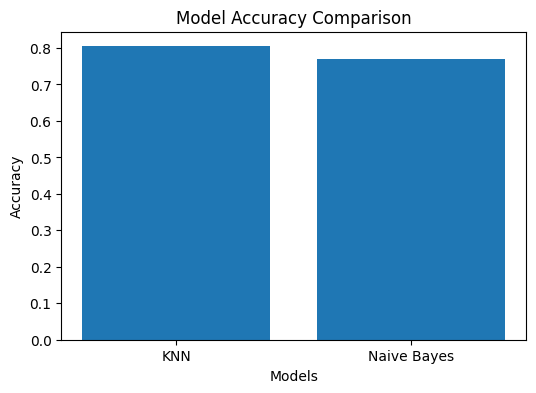

In [14]:
import matplotlib.pyplot as plt

models = ['KNN', 'Naive Bayes']
accuracies = [ac, ac1]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")


plt.show()

In [15]:
knn_proba=knn.predict_proba(X_test)
nb_proba=nb.predict_proba(X_test)

knn_auc=roc_auc_score(y_test,knn_proba[:,-1])
nb_auc=roc_auc_score(y_test,nb_proba[:,-1])

print(knn_auc)
print(nb_auc)

0.8626126126126126
0.8546975546975547
